# Logical Agents

Humans use what they know to make decisions and take actions. **Knowledge-based agents** follow the same principle: they use **reasoning** over an internal **knowledge representation** to determine their actions.  In contrast, **searching agents** have knowledge in a much narrower, task-specific form. They understand available actions and their outcomes but lack broader, general-purpose reasoning. For example, a route-finding agent doesn’t recognize that roads cannot have negative lengths, just as an 8-puzzle agent doesn't realize that two tiles cannot occupy the same space. Their knowledge is sufficient for achieving predefined goals but not for reasoning beyond their immediate tasks. To move toward more flexible behavior, Constraint Satisfaction Problems (CSPs) introduce a factored representation of states, where states are described as assignments of values to variables. This structure enables agents to operate in a more **domain-independent** way and supports the design of more **efficient algorithms**. Building on these ideas, we exploit **logic** as a powerful, general framework for representing knowledge in agents. Logical agents can **combine and restructure information** for different purposes, **accept new tasks** via **explicit goals**, **quickly acquire new skills** through learning or instruction, and **adapt** to changes in their environment by updating their knowledge base.

Why is this important? Today, approaches based on deep learning can be seen as equivalent to the sensory cortices of the brain, such as the visual or auditory cortex. However, true intelligence goes beyond perception, it requires the ability to recombine information into higher-level thinking and symbolic reasoning. Knowledge-Based agents are crucial because they can explicitly represent, reason about, and manipulate structured knowledge, filling the gap left by deep learning models that primarily rely on statistical pattern recognition without true understanding. A promising direction to address this limitation is **Neuro-Symbolic AI**, which combines the strengths of neural networks with symbolic reasoning. By integrating deep learning’s perceptual abilities with the structured reasoning of symbolic systems, Neuro-Symbolic AI aims to create more robust, interpretable, and flexible agents capable of deeper understanding and more adaptable behavior.

## Knowledge-Based Agents

At the heart of a knowledge-based agent lies the **knowledge base (KB)**, a collection of **sentences** expressed in a **knowledge representation language**. These sentences represent assertions about the world. This assertion can be **rules** (e.g. the if a person is parent of another person, then the first person is older than the second), or **facts** observed in the wordl( e.g. Riccardo is a parent of Alice). A sentence that is accepted as true without being derived from other sentences is called an **axiom** (e.g. the rules). The simplest sentences, called **atomic sentences**, consist of a single **symbol**. We use symbols that begin with an uppercase letter and may include other letters or subscripts, such as:

$\displaystyle P, Q, R, W_1$

To interact with the knowledge base, there must be a way to **add new sentences** (**TELL**) and a way to **query what is known** (**ASK**). Both operations may involve **inference**, the process of deriving new sentences from existing ones (e.g. "Is Riccardo older than Alice?"). We can define an abstract class to represent a generic knowledge base:

In [1]:
class KB:

    # Add the sentence to the KB
    def tell(self, sentence):
        raise NotImplementedError

    # Query the KB
    def ask(self, query):
        raise NotImplementedError

Inference must satisfy the requirement that when a query (ASK) is made to the knowledge base, the answer must **logically follow** from the information that has previously been added (TELLed) to it. With this in mind, we can outline the overall structure of a knowledge-based agent. It operates by continuously interacting with its environment through a cycle of perception, reasoning, and action. It maintains an internal KB, which stores facts and assertions about the world. When the agent perceives something in the environment, it adds the new information to the KB (TELL). To decide what to do, the agent **reasons** over its current knowledge. It formulates a query to determine what it knows and what conclusions can be drawn (ASK). Based on the outcome of this reasoning process, it selects an appropriate action. For example, if the KB contains the fact "Danger", the agent might decide to "Run", while if it knows "Food" is available, it might choose to "Eat." If no relevant information is found, the agent may default to an exploratory behavior, such as "Explore" to gather more knowledge After deciding, the agent performs the selected action, thereby affecting the environment. This, in turn, may generate new percepts, leading to updates in the KB and starting the cycle again. In this way, the agent uses its knowledge base not just to store information, but to drive intelligent, adaptive behavior based on what it perceives, what it infers, and how it acts.

## Logic

At the core of the humans reasoning there is **logic**: a formal system for representing knowledge and deriving conclusions. Logic provides a precise language for stating facts about a domain and systematic rules for manipulating those facts to reach new insights. We introduce the fundamental ideas and to make concepts concrete and intuitive, we will use arithmetic as a running example. Arithmetic is familiar, yet rich enough to illustrate the structure of logical statements, the role of inference, and the power of formal reasoning. To understand logic formally, we will introduce four key notions: **syntax**, which defines the structure and rules for forming valid sentences; **semantics**, which specifies the meaning of those sentences. In few words, we can summarize the two as follows:

- **Syntax**: what sentences are allowed?
- **Semantics**: what are the possible worlds? which sentences are true in which worlds?

Then we have **models**, which describe possible worlds where sentences are true or false; and **entailment**, the relationship that determines whether certain sentences logically follow from others. Logic forms the backbone of knowledge-based systems, enabling agents to reason about their environment, make decisions, and adapt to new situations with clarity and rigor.

### Syntax

The syntax defines the **formal structure of the language**, it specifies which symbols are allowed and how they can be combined to form **well-formed sentences**. Syntax is purely about the form of expressions, not their meaning. In arithmetic, we have a set of symbols that include numbers, variables, operators (like + and -), and parentheses. The syntax rules dictate how these symbols can be combined to create valid expressions. For example, "x+y = 4" is a well-formed sentence, while "x4y+ =" is not. In this case, the syntax rules specify that a variable must be followed by an operator, and that the equals sign must be preceded by a valid expression. In general, we have symbols for predicates, functions, constants, and logical connectives. 

### Semantic

The semantic defines **the meaning of sentences**. While syntax tells us how to form valid sentences, semantics tells us what those sentences mean and whether they are true or false in a given situation. It is based on an idea of a possible world, including objects, properties, and relationships involved. Each sentence is interpreted with respect to this possible world, and its truth value depends on it. In the arithmetic example, the sentence "x+y=4" can be interpreted in different ways depending on the values assigned to x and y. The truth of the sentence depends on the specific values of x and y in a given world. It is true in a world where x=2 and y=2 and false in a world where x=1 and y=1. Semantic connects the formal symbols of logic to their intended meanings and determines when sentences are true or false. In **standard logics**, there is no "in between" (every sentence must be either **true or false**), others type of logic, like the **fuzzy logic**, allow for degree of truth. 

### Models

A **model** is a structure that defines a specific possible world and tells us whether sentences are true in that world. For example, in arithmetic, a model could be a specific assignment of values to the variables. Each model provides a way to interpret the symbols and sentences of the language. In this context, a model is a mapping from the symbols of the language to their meanings in the real world. For instance, if we have a model where x=2 and y=2, then the sentence "x+y=4" is true in that model. If we change the model to x=1 and y=1, then the same sentence becomes false. The model **determines the truth of any sentence**. If a sentence is true in a model, we say that the model **satisfies** the sentence or that it **is a model of** the sentence. We use the notation 

M($\alpha$) 

to mean the set of all models of a sentence $\alpha$ (i.e., the set of all models that satisfy $\alpha$). For example, the models that satisfy the sentence "x+y=4" are all pairs of values (x,y) such that their sum equals 4. This includes pairs like (2,2), (1,3), and (0,4). The set of all such pairs is the model of the sentence.

### Entailment

We have a **notion of truth**, so we can introduce a notion of reasoning by formally define the idea that a sentence **follows logically** from another sentence. **Entailment** describes a relationship between sentences, one sentence (or set of sentences) logically entails another if, whenever the first sentences are true, the second must also be true. In mathematical notation, we write:

$\displaystyle A \models B$

The formal definition is as follows:

$\displaystyle A \models B \; \Leftrightarrow \; M(A) \subseteq M(B)$

This means that the set of models that satisfy A is a subset of the set of models that satisfy B. In other words, if a model satisfies A, it must also satisfy B. This relationship is crucial for reasoning, as it allows to draw conclusions based on known facts. The relation of entailment is familiar in arithmetic, we are happy with the idea that the sentence "x = 0" entails the sentence "x * y = 0". Obviously, in any model where x is zero, it is the case that x * y is zero (regardless of the value of y).

### Example: the Wumpus World

The **Wumpus World** is a classic example where knowledge-based agents can demonstrate their abilities. It consists of a cave made up of rooms connected by passages. Hidden somewhere is the Wumpus, a creature that will eat any agent entering its room. The agent can kill the Wumpus with a single arrow, but only has one chance. Some rooms also contain bottomless pits that trap any intruder. The only positive aspect of this dangerous world is the chance to find a pile of gold. The agent explores the environment using various sensors that provide information about nearby rooms.

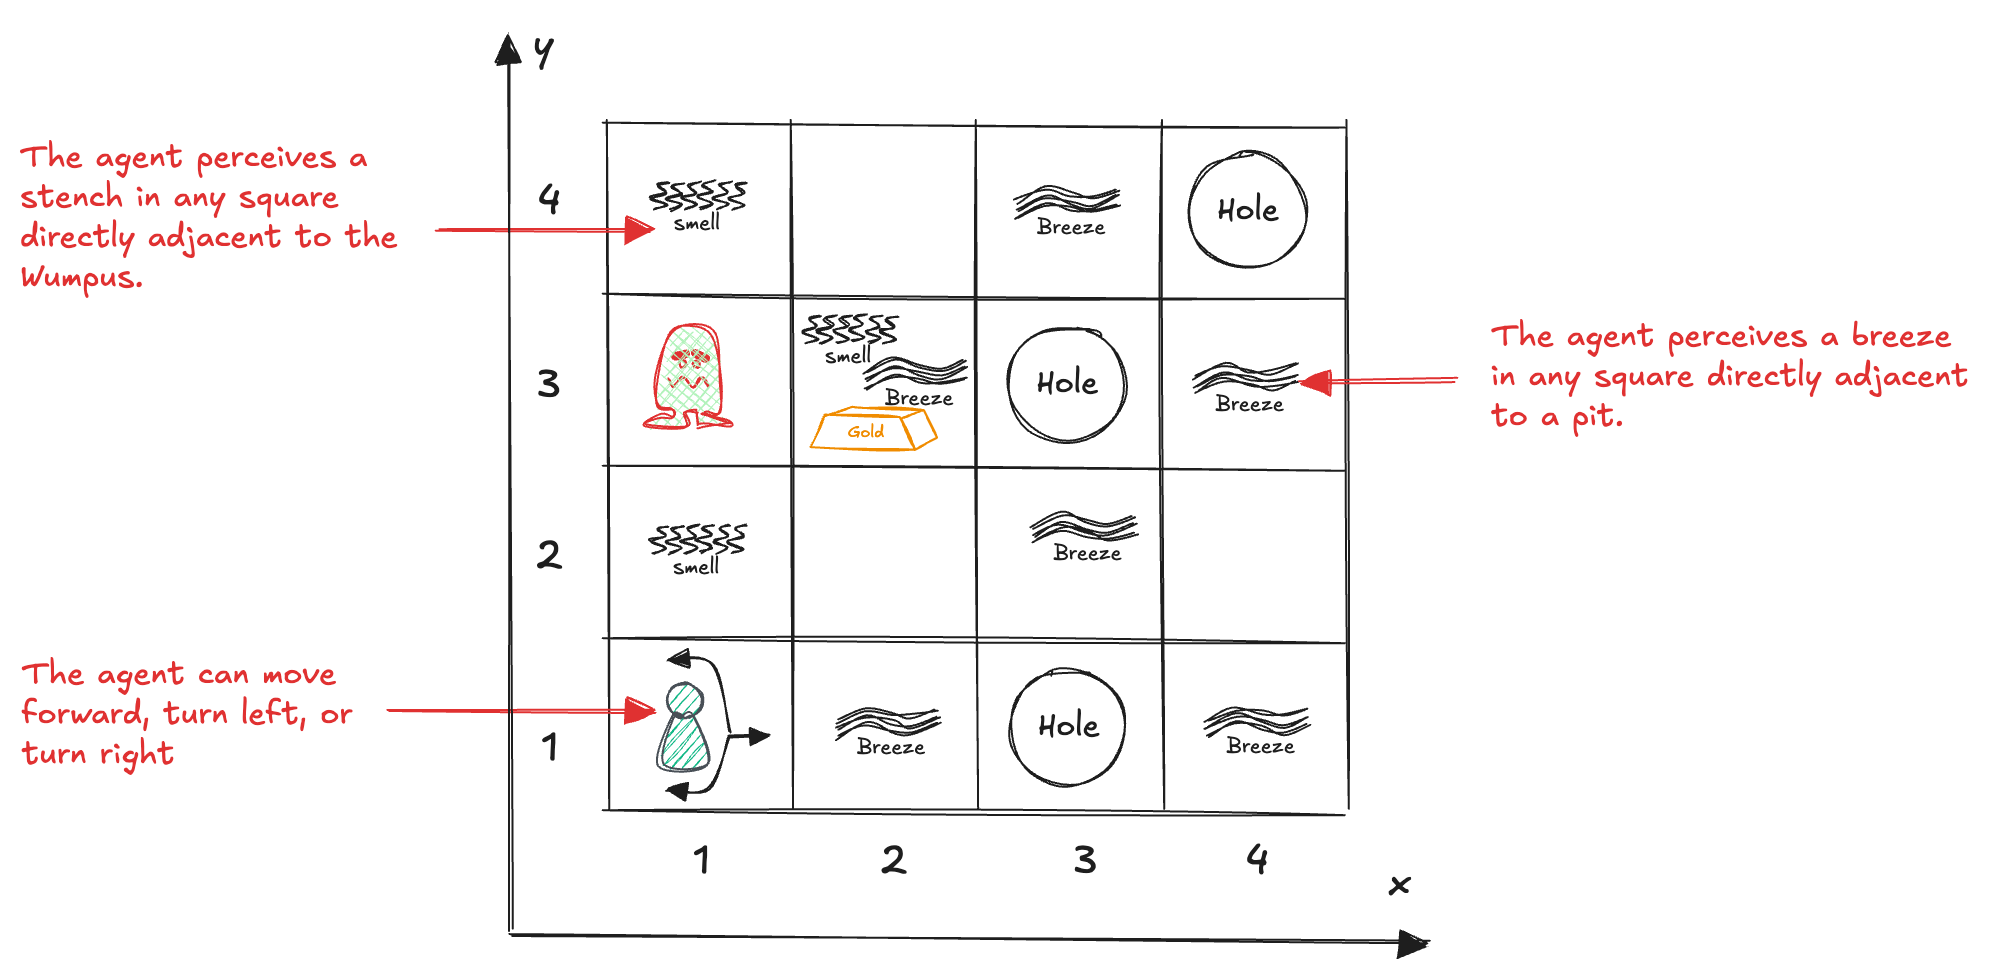

The Wumpus World is **deterministic**, **discrete**, **static**, and **single-agent**. It is also **sequential**, since rewards are typically achieved only after a series of actions. The environment is **partially observable** because certain aspects of the state (such as the locations of the pits and the Wumpus) are not directly perceivable. The main challenge for the agent lies in the **initial ignorance** of the world’s configuration. Overcoming this ignorance requires careful **logical reasoning** based on **limited percepts**. The agent must often decide whether to retreat safely without the gold or to risk death in the pursuit of greater rewards.

Let us observe an agent as it explores the environment, using an informal knowledge representation language where symbols are written directly onto a grid:

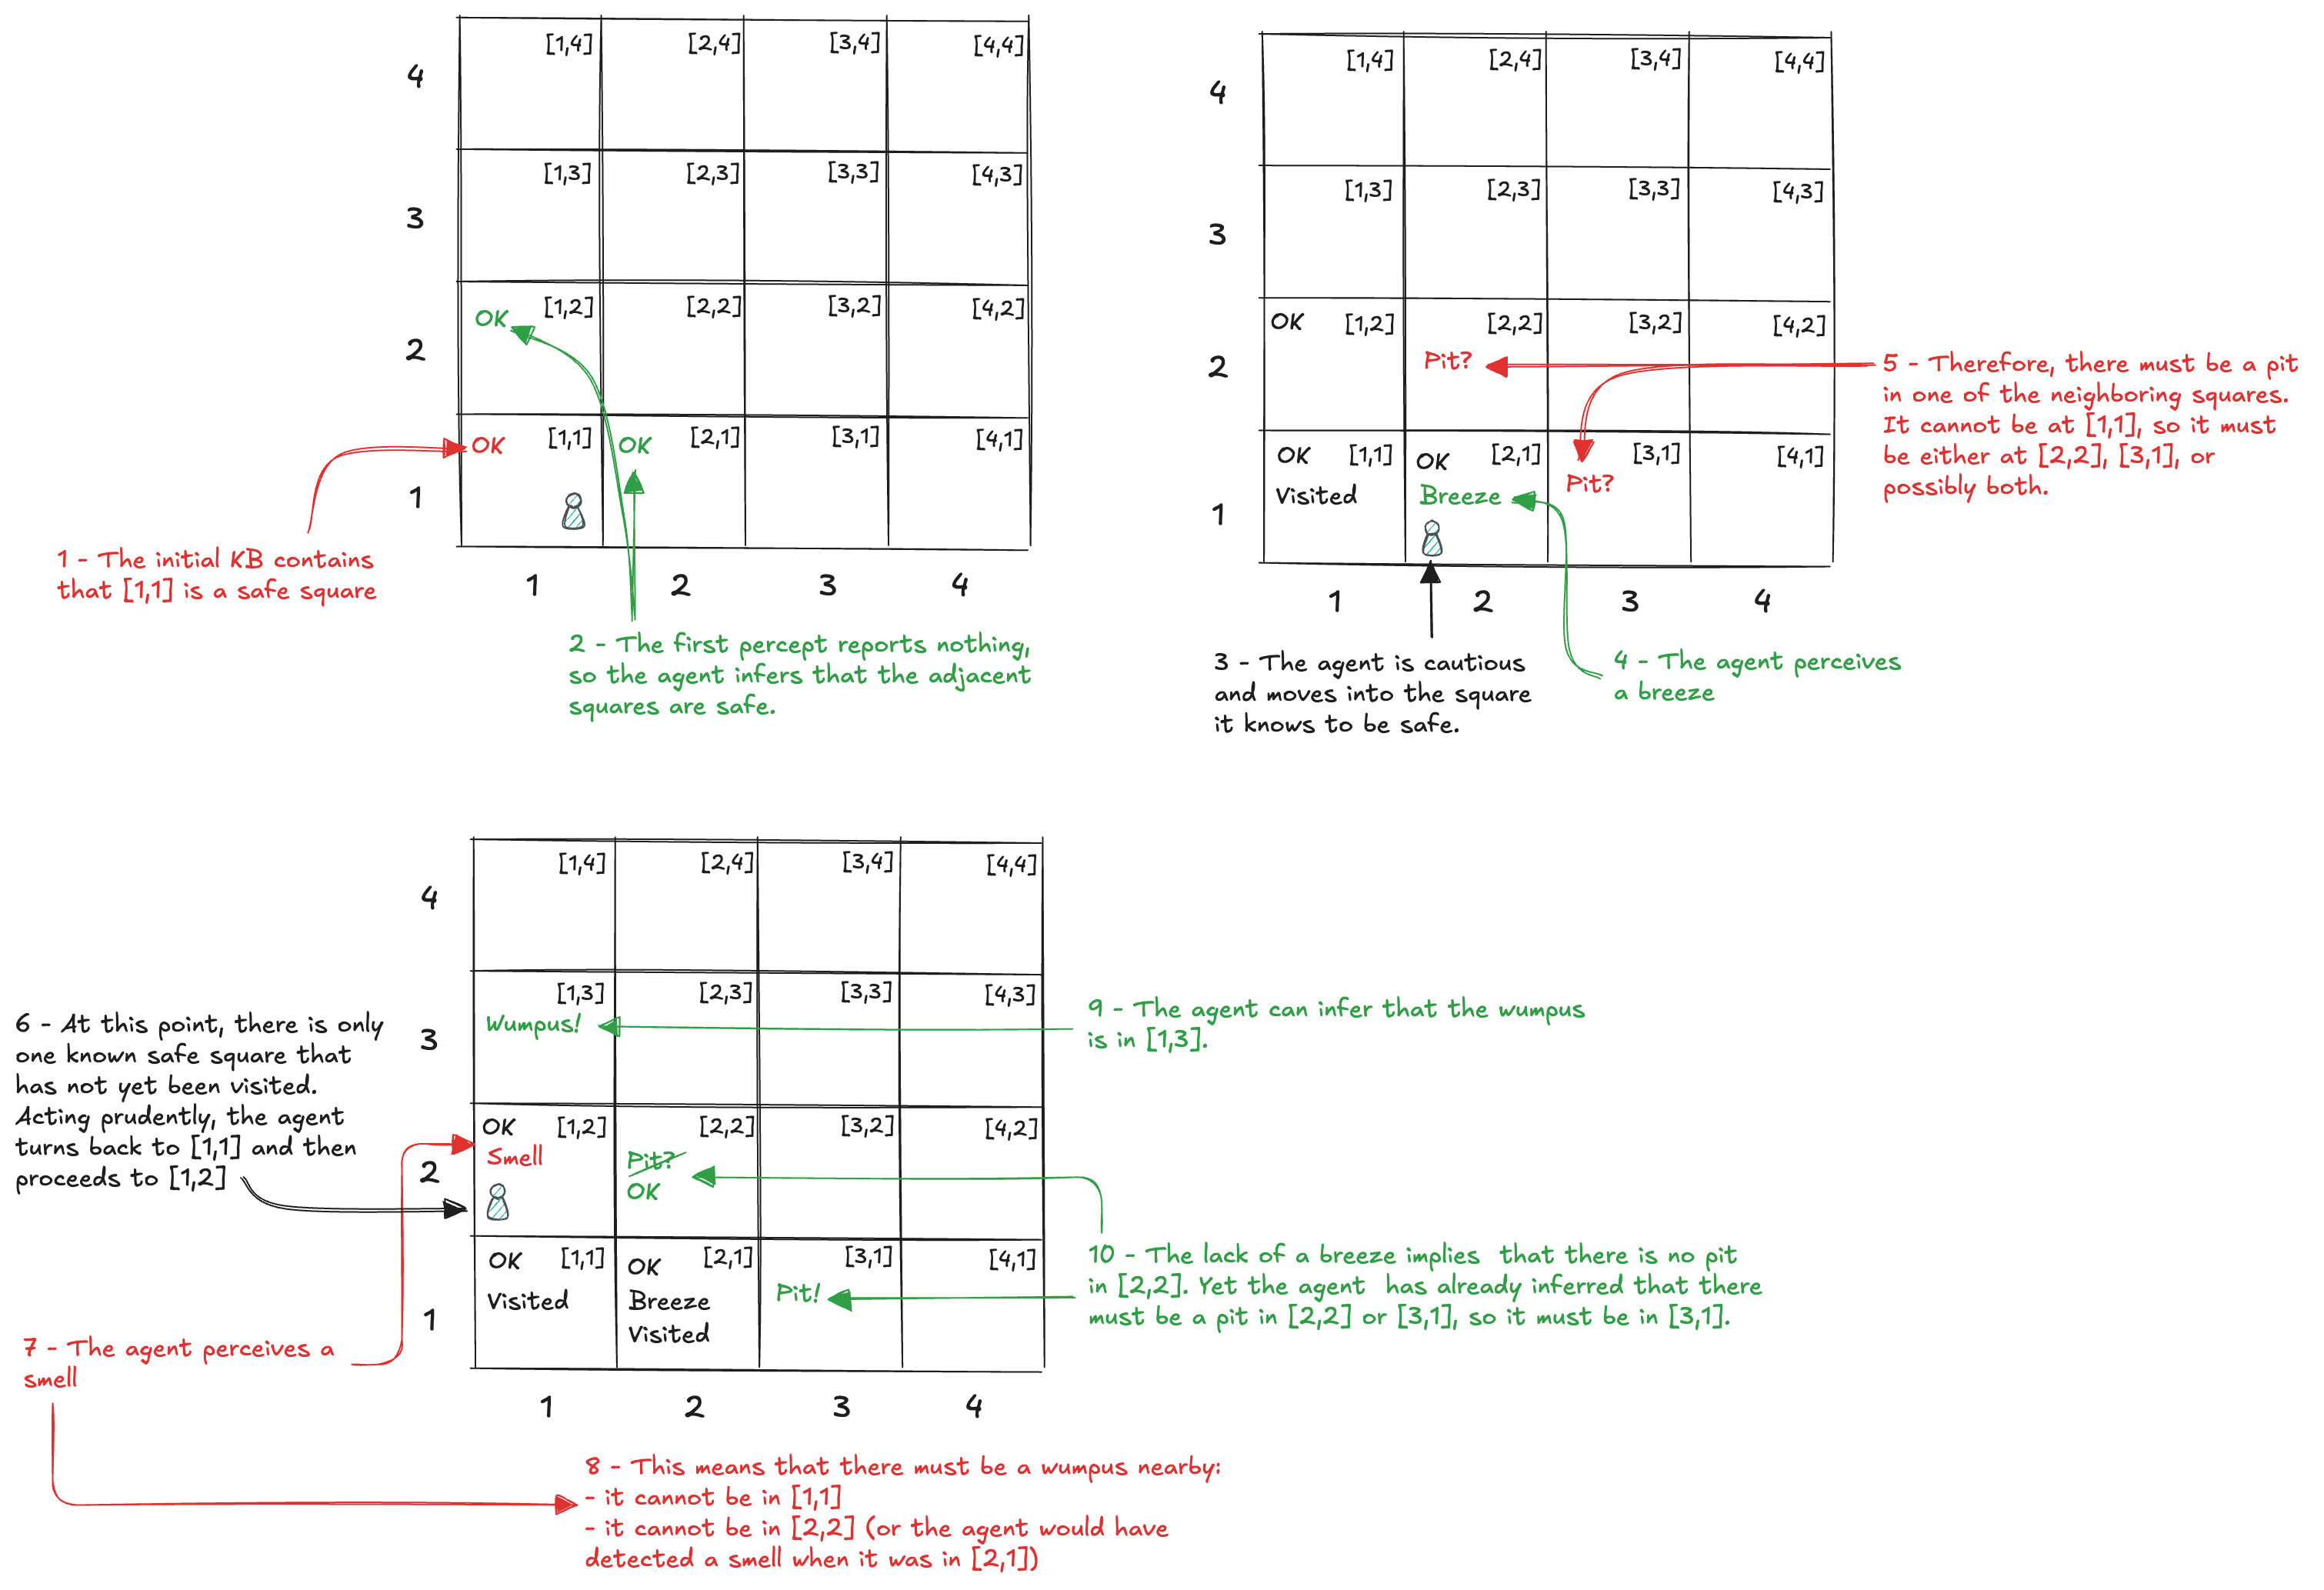

Notice that the final inference is quite challenging, as it **combines knowledge** gathered at different times and locations, and crucially depends on the **absence of a percept**. In every case where the agent infers something from the available information, the **conclusion is guaranteed to be correct**, provided that the information itself is accurate. This reliability is a fundamental property of **logical reasoning**.

We can apply logical analysis to this reasoning. Consider the situation after the agent's first action: the knowledge base can be viewed either as a collection of individual sentences or as a **single sentence that asserts their conjunction**. The KB is false in any model that contradicts what the agent knows.

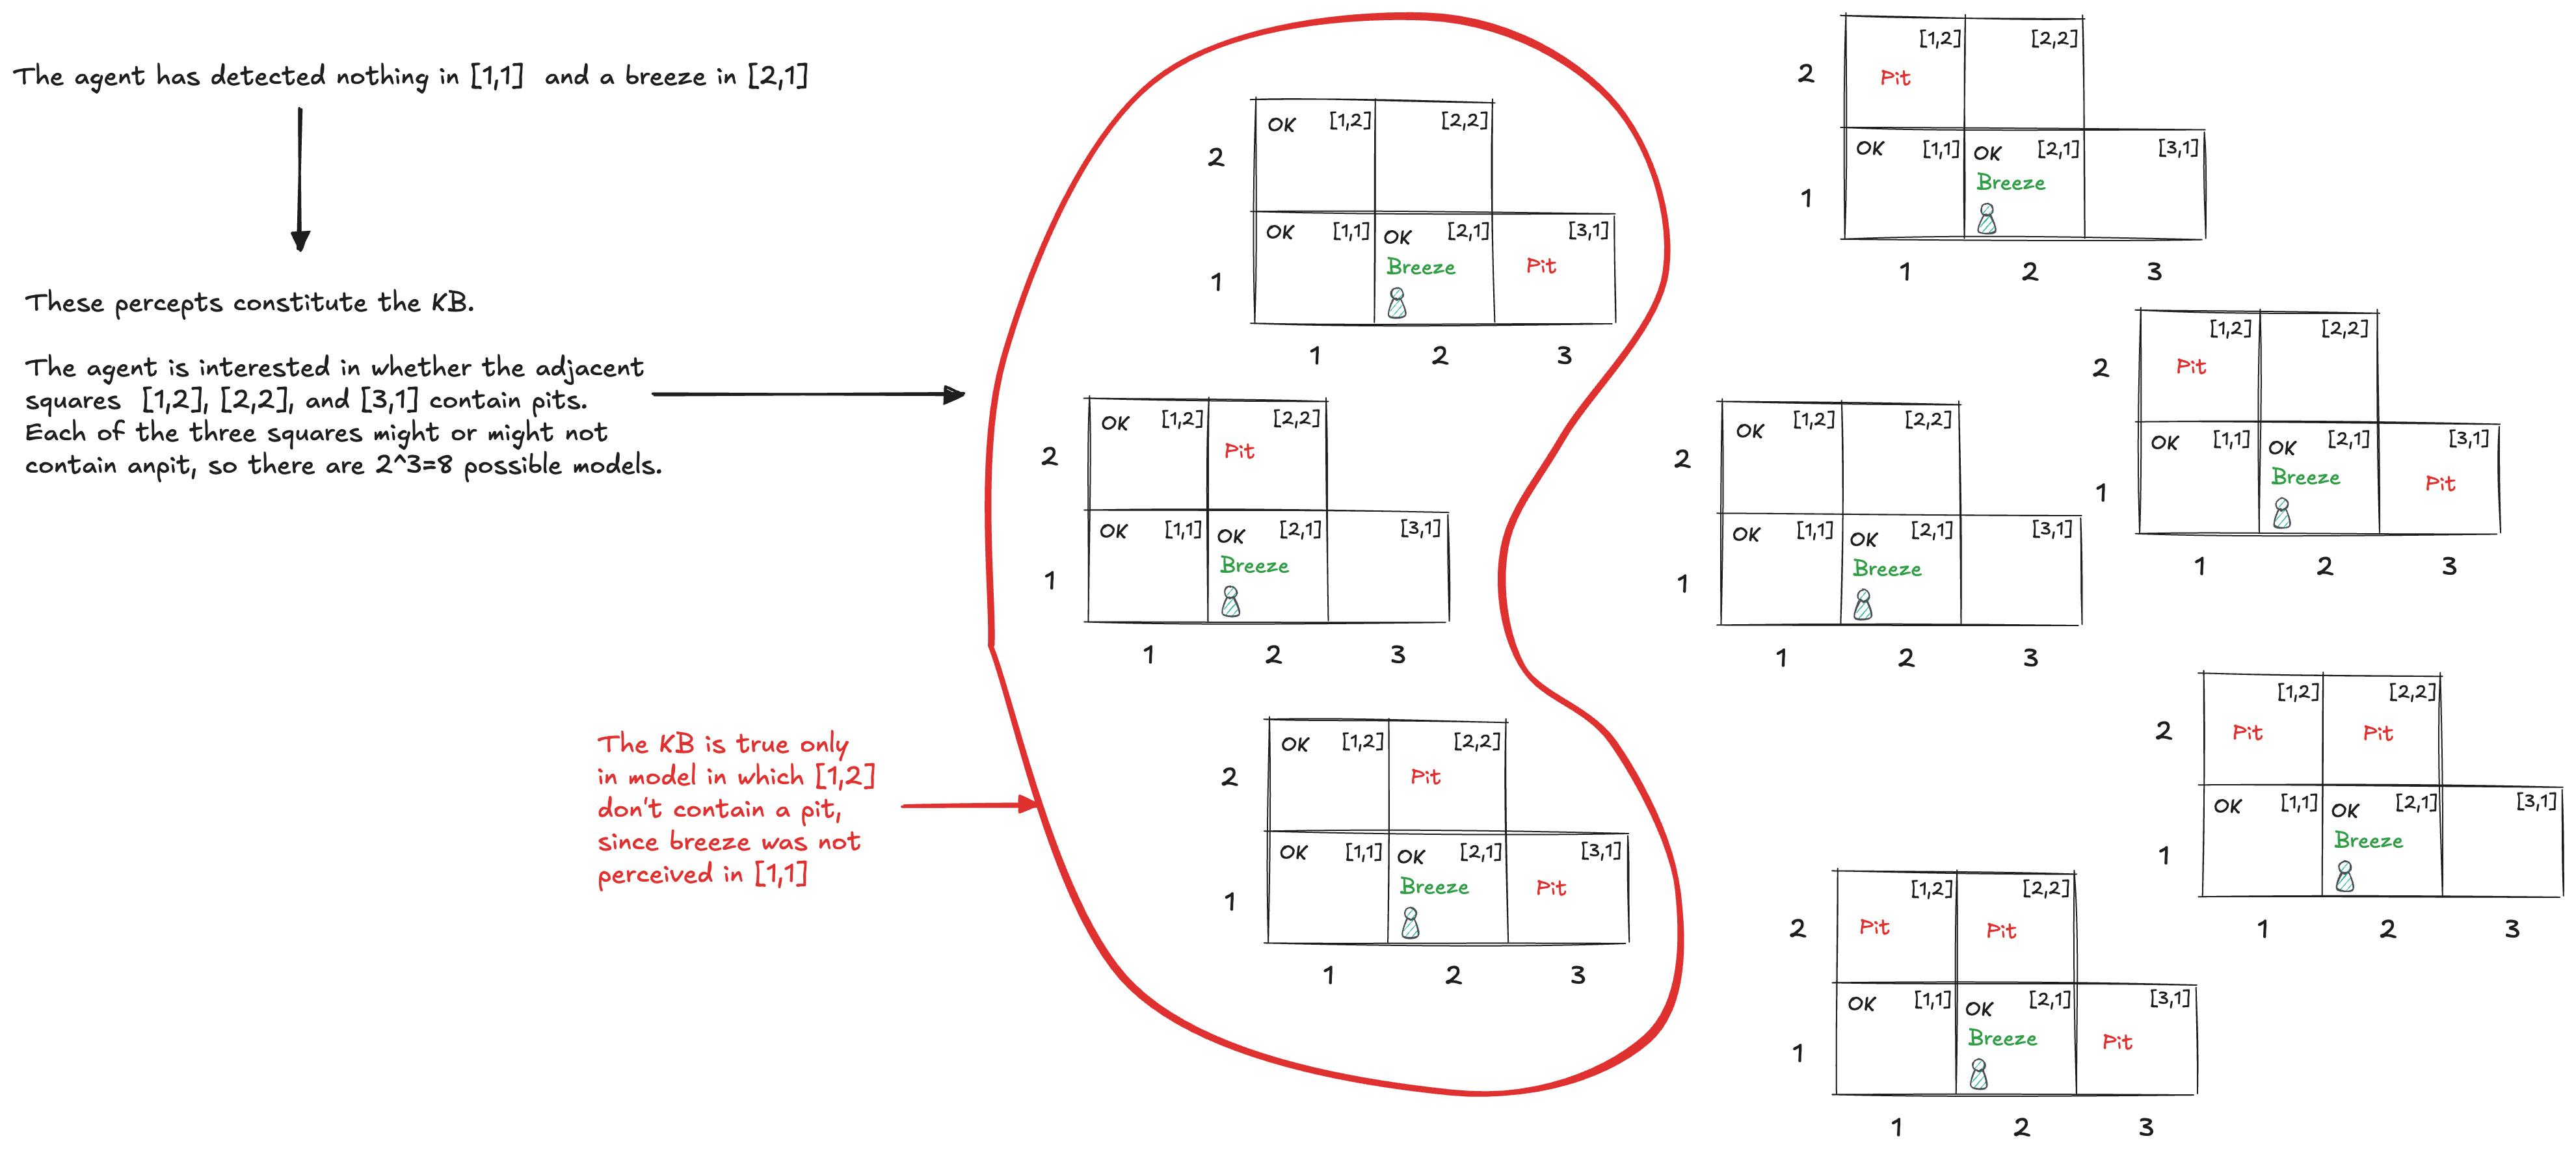

Now let us consider two possible new sentences: "There is a pit in [1,2]" and "There is a pit in [2,2]":

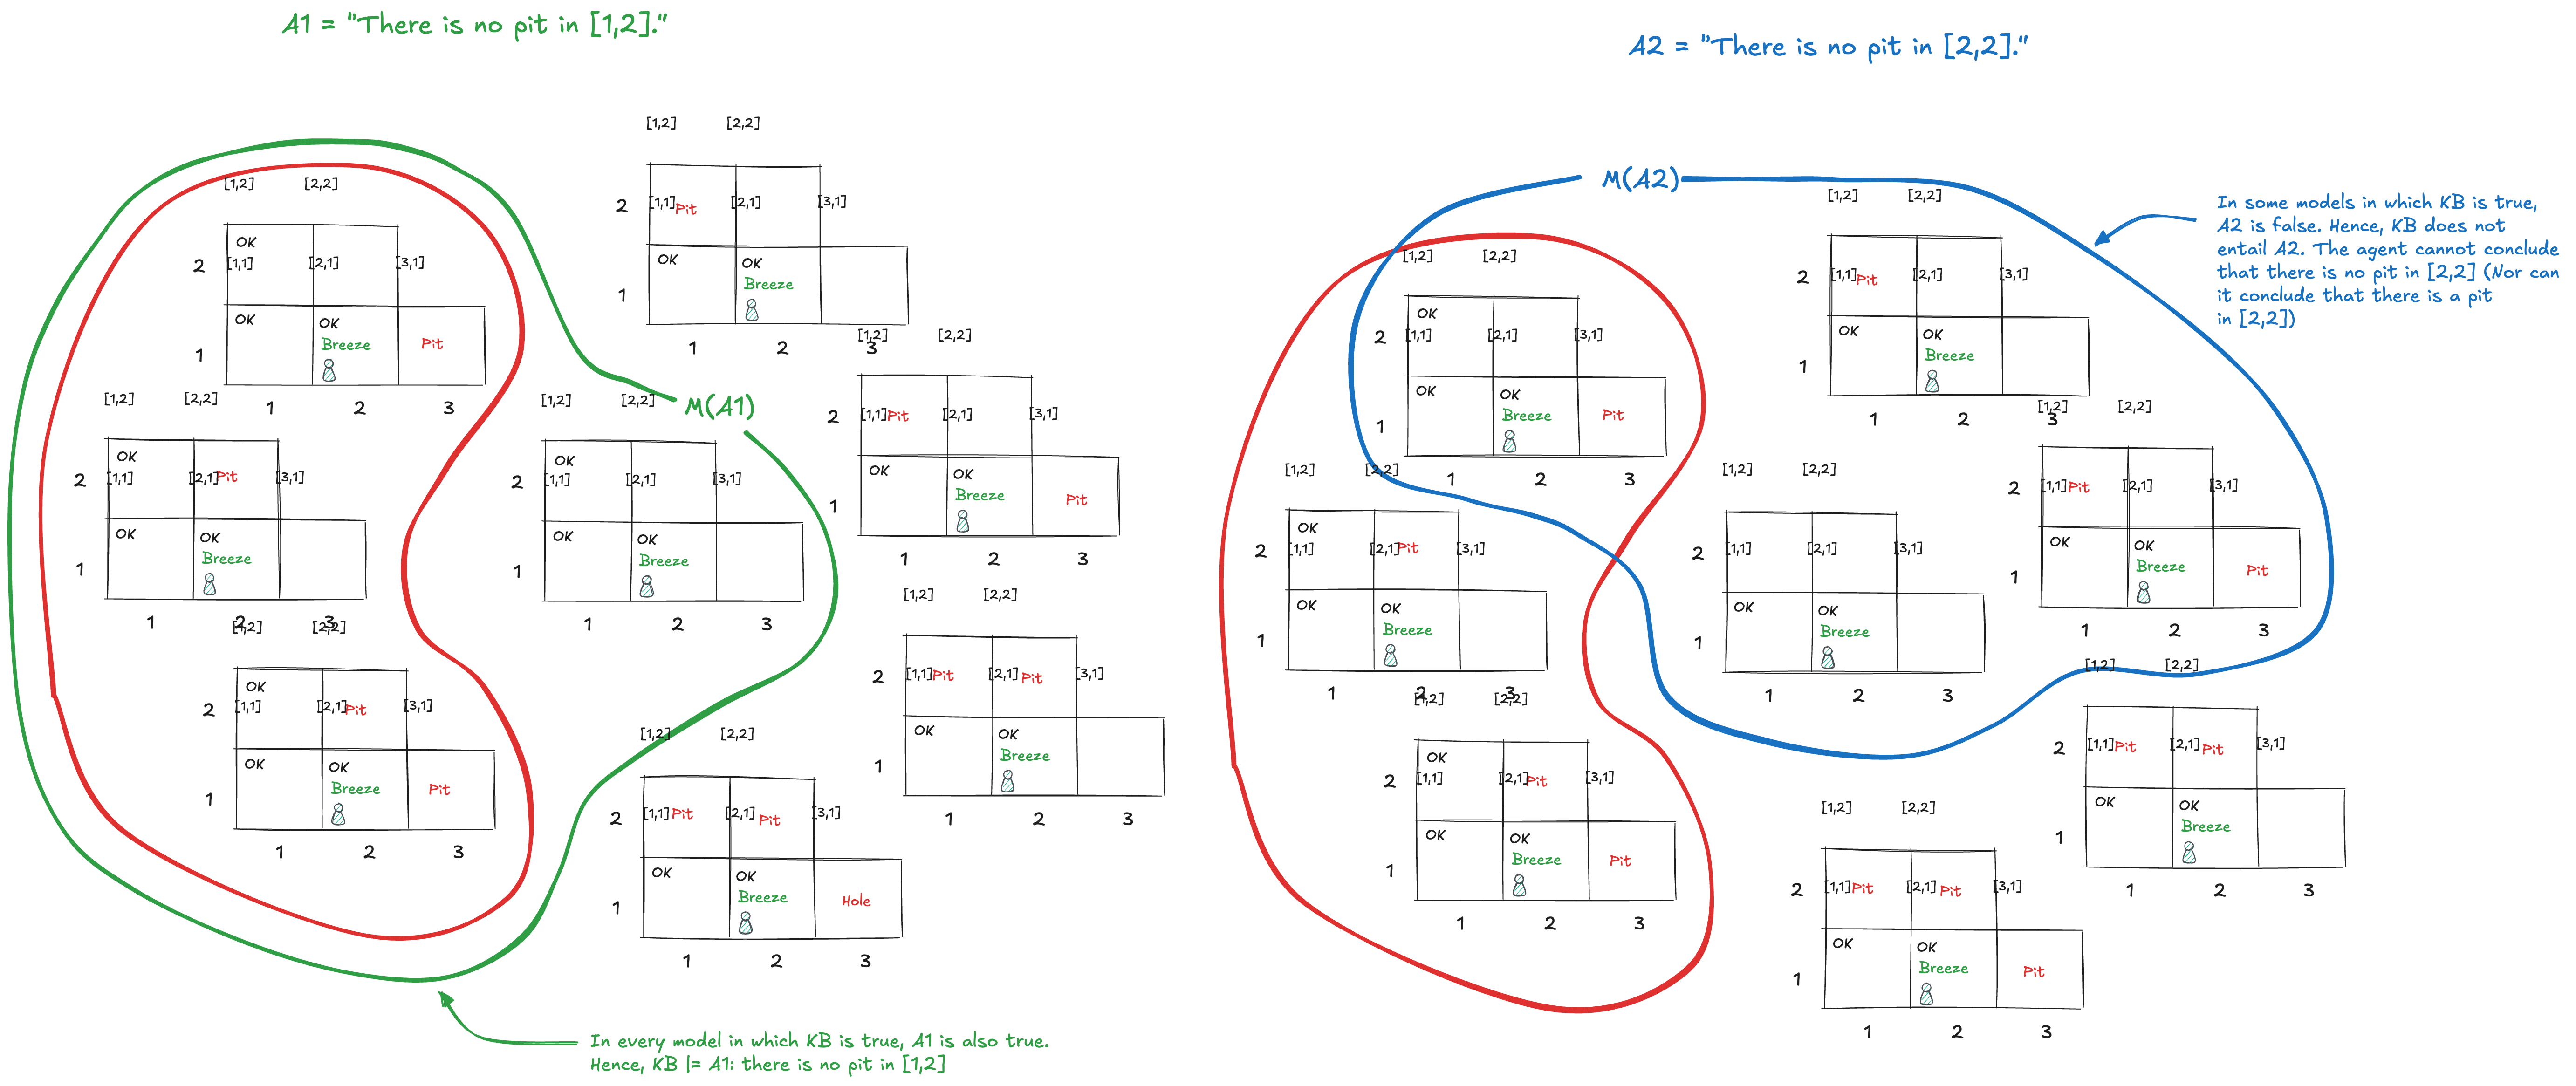

Some sentences are entailed by the KB, and some are not. The first sentence is entailed by the KB, because it is true in all models of the KB. The second sentence is not entailed by the KB, because it is false in some models of the KB.

### Inference

The Wumpus example illustrates the **process of logical inference**, where entailment enables us to derive conclusions from known information. The method used in the example is known as **model checking**, as it involves verifying whether a sentence A is true in all models where the knowledge base is true.

$\displaystyle M(\text{KB}) \subseteq M(A)$

If an inference algorithm i can derive a sentence A from a KB, we write:

$\displaystyle \text{KB} \vdash_i A$

This means "A is derived from KB by i" or equivalently "i derives A from KB". There are important properties that an inference algorithm can possess. An inference algorithm is said to be **sound** (or **truth-preserving**) if it derives only sentences that are actually entailed by the knowledge base. Soundness guarantees **correctness**, ensuring that no false conclusions are ever drawn. Model checking is sound, but it is practical only when the space of possible models is finite (for example, in fixed-size Wumpus worlds). In contrast, domains like arithmetic involve infinite models, there are, for instance, infinitely many pairs of integers that satisfy the sentence "x+y=4". An inference algorithm is **complete** if it can derive every sentence that is entailed by the knowledge base. For finite knowledge bases, completeness is relatively straightforward: a systematic examination of all possibilities can always determine entailment. However, many real-world knowledge bases have infinitely many consequences, making completeness an essential and nontrivial property.

Notice that, although inference **operates on the syntax** of sentences (such as symbols), it ultimately **captures semantics**, the real-world relationships between facts. As Wittgenstein famously put it: "The world is everything that is the case". Thus, if the knowledge base (KB) accurately reflects the real world, any sentence derived from it by a sound inference procedure will also be true in the real world:

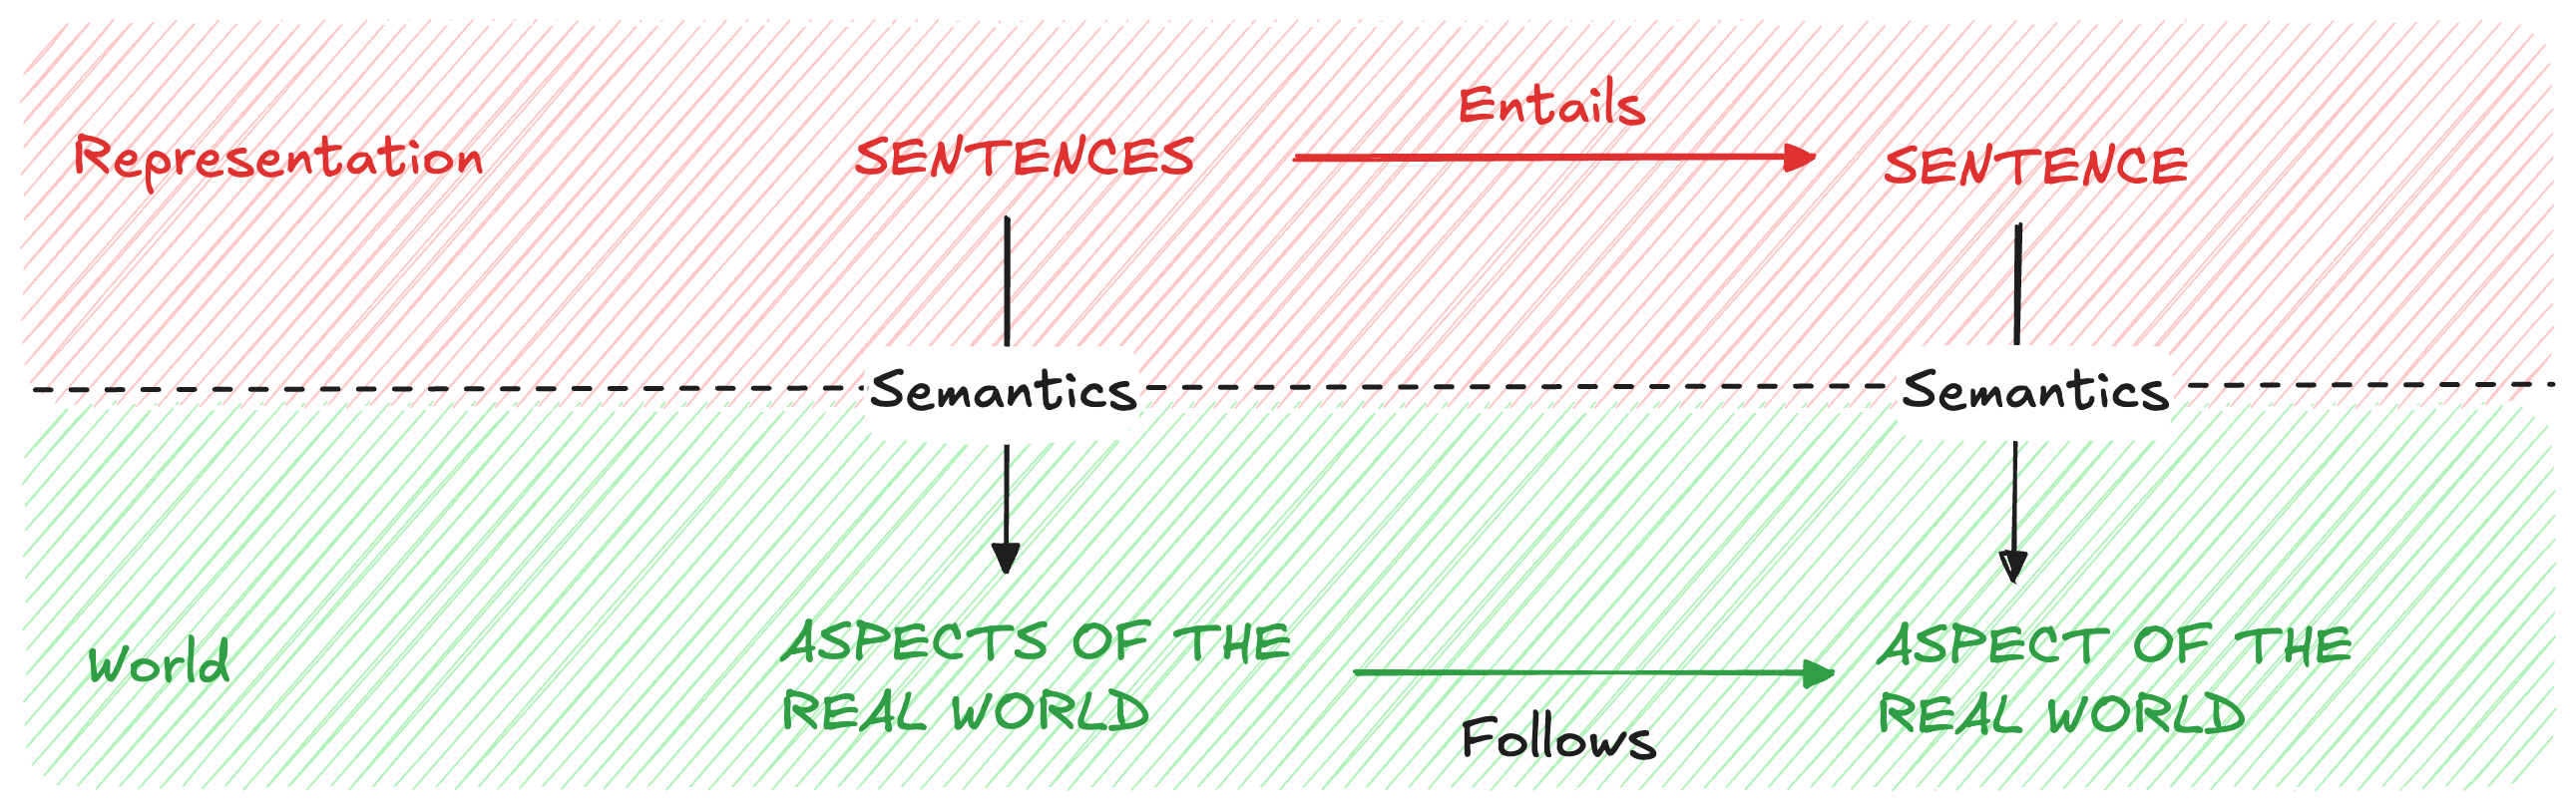

A final issue to consider is **grounding**, the problem of **connecting the agent’s internal symbolic representations to the external world**. The knowledge base consists of syntactic structures (sentences) but the crucial question is how these structures come to represent **facts about reality**. Since the KB exists purely as syntax within the agent, this presents a **fundamental philosophical challenge**. In practice, grounding is achieved through **sensors**, which mediate between the agent and its environment. For instance, in the Wumpus World, the detection of a smell by a sensor results in the addition of a corresponding sentence to the KB, which is considered true by virtue of the sensing process. In this way, the truth and meaning of **perceptual knowledge** is directly tied to the mechanisms by which is is generated. Beyond direct perception, the agent also relies on **abstract knowledge**, such as the rule that a Wumpus generates a smell in adjacent squares. Such rules are not direct observations but **generalizations formed through learning**. While learned knowledge may not guarantee absolute correctness, robust learning algorithms can ensure that the KB remains closely aligned with the structure of the real world.

## Propositional Logic

We begin by introducing **propositional logic**, the simplest and most fundamental form of logic. Although limited in expressive power, propositional logic provides the foundation for more sophisticated logical systems. We first present its syntax, which defines the structure of well-formed sentences, and its semantics, which specifies how the truth of sentences is determined relative to a model. Building on these definitions, we develop a basic syntactic algorithm for logical inference that correctly captures the semantic notion of entailment.

### Syntax

The **atomic sentences** consist of a single symbol (A, B, C) that can be true or false. **Complex sentences** are constructed from simpler sentences, using parentheses and **logical connectives** operators:
- **Not ¬**. A sentence such as ¬A is called the negation of A.
- **And ∧**. A sentence A ∧ B is called a **conjunction**, its parts are the **conjuncts**.
- **Or ∨**. A sentence A v B is a **disjunction**, its parts are **disjuncts**.
- **Implies ⇒**. A sentence A ⇒ B is called an **implication**. Its **premise** or **antecedent** is A and its **conclusion** or **consequent** is B. Implications are also known as **rules** or **if–then statements**.
- **If and only if (iff) ⇔**. The sentence A ⇔ B, is a **biconditional**.
  
To define the set of sentences in propositional logic, we introduce a **grammar**, a set of rules that specifies how valid sentences are constructed. A grammar lays out the permissible ways in which symbols can be combined to form well-structured sentences. Specifically, we use the **Backus–Naur Form**, a standard notation for describing the syntax of formal systems. Production rules state how complex expressions are built from simpler components, providing a clear and systematic description of all the sentences allowed:

- Sentence → AtomicSentence | ComplexSentence
- AtomicSentence → True | False | A | B | C | ...
- ComplexSentence → Sentence | ¬ Sentence | Sentence ∧ Sentence | Sentence ∨ Sentence | Sentence ⇒ Sentence | Sentence ⇔ Sentence
- Operator precedence (from highest to lowest): ¬, ∧, ∨, ⇒, ⇔

We can implement in Python a minimalistic senteces support, where atomic sentences are represented as strings (like "A", "B", "C") and complex sentences as lists where the first element is a logical operator ("NOT", "AND", "OR", "IMPLIES", "IFF"), and the remaining elements are the sub-sentences:

In [2]:
class Sentence:
    operators = {"NOT", "AND", "OR", "IMPLIES", "IFF"}

    # Initialize the sentence, which can be atomic (a string) or complex (a list)
    def __init__(self, content):
        self.content = content

    # Check if the sentence is atomic (a single symbol)
    def is_atomic(self):
        return isinstance(self.content, str)

    # Check if the sentence is complex (a list with an operator as the first element)
    def is_complex(self):
        return isinstance(self.content, list) and self.content[0] in self.operators

    # Check if the sentence is well-formed according to propositional logic rules
    def is_well_formed(self):
        if self.is_atomic():
            return True

        if not self.is_complex():
            return False
        
        op = self.content[0]
        args = self.content[1:]

        if op == "NOT":
            return len(args) == 1 and all(isinstance(arg, Sentence) and arg.is_well_formed() for arg in args)

        elif op in {"AND", "OR"}:
            return len(args) >= 2 and all(isinstance(arg, Sentence) and arg.is_well_formed() for arg in args)

        elif op in {"IMPLIES", "IFF"}:
            return len(args) == 2 and all(isinstance(arg, Sentence) and arg.is_well_formed() for arg in args)

        else:
            return False

    # Convert the sentence to a string representation
    def stringify(self):
        if self.is_atomic():
            return self.content

        op = self.content[0]
        args = self.content[1:]

        if op == "NOT":
            return f"¬{args[0].stringify()}"
        
        if op == "AND":
            return "(" + " ∧ ".join(arg.stringify() for arg in args) + ")"

        if op == "OR":
            return "(" + " ∨ ".join(arg.stringify() for arg in args) + ")"

        if op == "IMPLIES":
            return f"({args[0].stringify()} ⇒ {args[1].stringify()})"

        if op == "IFF":
            return f"({args[0].stringify()} ⇔ {args[1].stringify()})"

        return "UNKNOWN"


For example, we can write some sentences and check their correctness:

In [3]:
# Some example of atomic sentences
P = Sentence("P")
Q = Sentence("Q")
R = Sentence("R")

# A complex sentence: (P ∧ (¬Q)) ⇒ R
complex_sentence = Sentence(["IMPLIES",
                              Sentence(["AND", P, Sentence(["NOT", Q])]),
                              R])

# Print the string representation of the complex sentence
print(complex_sentence.stringify()) 

# Well-formedness check
print(complex_sentence.is_well_formed()) 

# Example of a not well-formed sentence
not_well_formed_sentence = Sentence(["NOT", P, Q, R])
print(not_well_formed_sentence.is_well_formed())

((P ∧ ¬Q) ⇒ R)
True
False


### Semantics

The semantics of propositional logic defines how the truth of a sentence is determined relative to a model. A model in propositional logic is a complete assignment of truth values (true or false) to each atomic proposition symbol. For example, if the sentences in the knowledge base make use of the proposition symbols 

$\displaystyle A, B, C$ 

then one possible model is 

$\displaystyle m = \{A = \text{false}, B = \text{false}, C = \text{true}\}$.

With three proposition symbols, there are 2^3=8 possible models. Notice that the models are **purely mathematical objects** with no necessary connection to a real worlds. A is just a symbol, it might mean "there is a pit in [1,2]" or "I’m in Paris today and tomorrow". Once a model is given, the truth of more complex sentences is evaluated recursively based on the meanings of the logical connectives:

- ¬A is true if and only if A is false
- A ∧ B is true if and only if both A and B are true
- A ∨ B is true if and only if either A or B is true
- A ⇒ P is true unless A is true and B is false
- A ⇔ B is true if and only if A and B are both true or both false

The rules can be expressed with **truth tables** that specify the truth value of a complex sentence for each possible assignment of truth values to its components:

| A     | B     | ¬A    | A ∧ B | A ∨ B | A ⇒ B | A ⇔ B |
|-------|-------|-------|-------|-------|-------|-------|
| false | false | true  | false | false | true  | true  |
| false | true  | true  | false | true  | true  | false |
| true  | false | false | false | true  | false | false |
| true  | true  | false | true  | true  | true  | true  |

From these tables, the truth value of a sentence can be computed with respect to a model by a simple recursive evaluation. For example, the sentence:

$\displaystyle ¬A ∧ (B ∨ C)$ 

evaluated in m, gives 

$\displaystyle \text{true} ∧ (\text{false} ∨ \text{true}) = \text{true} ∧ \text{true} = \text{true}$

The truth table entries for "and", "or", and "not" closely match intuition. However, a common point of confusion arises with "or": in propositional logic, "or" is inclusive, meaning the sentence is true if either the first part, the second part, or both are true. In contrast, a different connective known as "exclusive or" (often abbreviated as XOR) is true only when exactly one of the two sentences is true, and false when both are true. Instead, the truth table for "implies" may not fit intuitive understanding. For one thing, propositional logic **does not require any relation of causation** between the two sentence. The sentence "5 is odd implies Tokyo is the capital of Japan" is a true sentence, even though it is bizarre. Another point of confusion is that **any implication is true whenever its antecedent is false**. For example, "5 is even implies Sam is smart" is true, regardless of whether Sam is smart. This seems strange, but it makes sense if we think of "A ⇒ B" as "if A is true, then I am claiming that B is true; otherwise I am making no claim". The only way for this sentence to be false is if A is true but B is false. The biconditional is true whenever both implies are true.

We can write an evaluate() method to check the truth of a sentence in a model, where the model is a dictionary of symbols and their truth values. The method will recursively evaluate the sentence based on the logical connectives and the model provided:

In [4]:
def evaluate(sentence, model):

    if sentence.is_atomic():
        return model.get(sentence.content, False)

    op = sentence.content[0]
    args = sentence.content[1:]

    if op == "NOT":
        return not evaluate(args[0], model)

    if op == "AND":
        return all(evaluate(arg, model) for arg in args)

    if op == "OR":
        return any(evaluate(arg, model) for arg in args)

    if op == "IMPLIES":
        return (not evaluate(args[0], model)) or evaluate(args[1], model)

    if op == "IFF":
        return evaluate(args[0], model) == evaluate(args[1], model)

    raise ValueError(f"Unknown operator: {op}")

We can evaluate some examples of sentences in a model:

In [5]:
# Define atomic sentences
P = Sentence("P")
Q = Sentence("Q")
R = Sentence("R")

# Model (truth assignment)
model = {"P": True, "Q": False, "R": True}

# Build a complex sentence: (P ∧ ¬Q) ⇒ R
sentence = Sentence(["IMPLIES",
                     Sentence(["AND", P, Sentence(["NOT", Q])]),
                     R])
print(sentence.stringify()) 

# Evaluate
print(evaluate(sentence, model)) 

((P ∧ ¬Q) ⇒ R)
True


We can write the true table for a sentence, which is the evaluatoin of the sentence in all possible models. First of all we need to extract all the symbols from the sentence. We can do this by recursively traversing the sentence and collecting all the symbols in a set:

In [6]:
def get_symbols(sentence):

    # If the sentence is atomic, return its content
    if sentence.is_atomic():
        return {sentence.content}

    # Else, extract symbols from the sentence recursively
    else:
        symbols = set()
        for arg in sentence.content[1:]:
            symbols.update(get_symbols(arg))
        return symbols

Then we can generate all possible models by creating all combinations of truth values for the symbols. Finally, we can evaluate the sentence in each model and print the results in a table format:

In [7]:
import itertools

def truth_table(sentence):

    # Collect all symbols in the sentence
    symbols = sorted(list(get_symbols(sentence)))

    # Create header
    header = " | ".join(symbols) + " || Expr"
    print(header)
    print("-" * len(header))

    # Generate all possible truth assignments
    for values in itertools.product([True, False], repeat=len(symbols)):
        model = dict(zip(symbols, values))

        # Evaluate the sentence
        result = evaluate(sentence, model)

        # Build the row
        symbol_row = " | ".join("T" if model[s] else "F" for s in symbols)
        result_row = "T" if result else "F"

        print(f"{symbol_row} || {result_row}")

We can make and example of the truth table for a simple sentence:

In [8]:
# Let's build a logical expression: (P ∧ Q) v R
P = Sentence("P")
Q = Sentence("Q")
R = Sentence("R")

expr = Sentence(["OR",
                 Sentence(["AND", P, Q]),
                 R])

# Print the truth table
truth_table(expr)

P | Q | R || Expr
-----------------
T | T | T || T
T | T | F || T
T | F | T || T
T | F | F || F
F | T | T || T
F | T | F || F
F | F | T || T
F | F | F || F


### Knowledge Base

The knowledge base is a collection of sentences that represent the agent's knowledge about the world. The KB is used to store information that the agent has learned or inferred, and it is updated as the agent interacts with its environment. The KB can be thought of as a **database** of facts, rules, and relationships that the agent can use to reason about its actions and make decisions. We can write a class to represent the KB, which will allow us to add new sentences:

In [9]:
class PL_KB(KB):
    def __init__(self):
        self.sentences = []

    def tell(self, sentence):

        # Check if the sentence is a valid Sentence object
        if not isinstance(sentence, Sentence):
            raise ValueError("Only Sentence objects can be added to the KB.")
        
        # Check if the sentence is well-formed
        if not sentence.is_well_formed():
            raise ValueError("Cannot add malformed sentences.")
            
        # Add the sentence to the KB
        self.sentences.append(sentence)

As discussed, the KB can be seen as a single sentence that asserts the conjunction of all sentences in the KB. So we can define the true table for the KB:

In [10]:
def kb_truth_table(kb):

    sentence = None

    # Check if the KB is empty
    if not kb.sentences:
        raise ValueError("Knowledge base is empty.")
    
    # Check if the KB has more than one sentence
    if len(kb.sentences) == 1:
        sentence = kb.sentences[0]
    
    # If the KB has more than one sentence, combine them with AND
    else:
        sentence = Sentence(["AND"] + kb.sentences)

    return truth_table(sentence)

We can make an simple example of a KB:

In [13]:
# Define atomic propositions
P = Sentence("P")
Q = Sentence("Q")
R = Sentence("R")

# Create the KB
kb = PL_KB()

# Add sentences to the KB

# 1. P ⇒ Q
kb.tell(Sentence(["IMPLIES", P, Q]))

# 2. R
kb.tell(R)

# 3. Q ∨ R
kb.tell(Sentence(["OR", Q, R]))

# Print the truth table for the KB
kb_truth_table(kb)

P | Q | R || Expr
-----------------
T | T | T || T
T | T | F || F
T | F | T || F
T | F | F || F
F | T | T || T
F | T | F || F
F | F | T || T
F | F | F || F


### Moel Checking

In propositional logic, inference allows us to draw conclusions that must be true if the original sentences (the knowledge base) are true. A simple method of inference is **model checking**, that is a direct implementation of the definition of entailment: systematically examining all possible models to see whether a sentence holds in all models where the KB is true.  We can implement a simple inference() method that generates all possible models and check if the sentence is true in all of them:

In [14]:
import itertools

def ask(self, query):
    # Collect all symbols from the KB and the query
    symbols = set()
    for sentence in kb.sentences:
        symbols.update(get_symbols(sentence))
    symbols.update(get_symbols(query))
    symbols = list(symbols)

    # Generate all possible truth assignments (models)
    for values in itertools.product([True, False], repeat=len(symbols)):
        model = dict(zip(symbols, values))

        # Only consider models where KB is true
        if all(evaluate(sentence, model) for sentence in kb.sentences):
            query_value = evaluate(query, model)
            if not evaluate(query, model):
                # Found a counterexample
                return False  
                
    # No counterexamples: entailment holds
    return True  

PL_KB.ask = ask 

We can use the method to show some example of inference. First we consider a **simple logical consequence**, like P ⇒ Q, P ⊨ Q?:

In [15]:
# Create a knowledge base
kb = PL_KB()

# Create two atomic sentences
P = Sentence("P")
Q = Sentence("Q")

# Create a complex sentence: P IMPLIES Q
S1 = Sentence(["IMPLIES", P, Q])

# Add some knowledge to the KB
kb.tell(P)
kb.tell(S1)

# Query: Does P entail Q?
query = Q
print(kb.ask(query)) 

True


A non trivial case, with multiple premises: (P ⇒ Q) ∧ (Q ⇒ R), P ⊨ R? Here, the chain of implicationsis: if P then Q, and if Q then R, and we know P, then R must be true:

In [17]:
kb = PL_KB()

P = Sentence("P")
Q = Sentence("Q")
R = Sentence("R")

# Add the sentente "if P then Q"
kb.tell(Sentence(["IMPLIES", P, Q]))

# Add the sentence "if Q then R"
kb.tell(Sentence(["IMPLIES", Q, R]))

# Add the sentence "we know P"
kb.tell(P)

# Ask about R
query = R
print(kb.ask(query))  

True


We can consider a situation where the inference is false: P ⇒ Q, no knowledge about P, and we query about Q. In that case, we know that "P implies Q", but we don't know if P is true, so we cannot conclude anything about Q:

In [18]:
kb = PL_KB()

P = Sentence("P")
Q = Sentence("Q")

kb.tell(Sentence(["IMPLIES", P, Q]))

query = Q
print(kb.ask(query)) 

False


Notice that if the knowledge base answers false to a query, this does not necessarily mean that the statement itself is false in the real world. It only means that, based on the current information in the KB, the statement cannot be logically inferred as true. A False answer from the KB means **not currently entailed**, not necessarily **definitely false**. New knowledge added later could allow the KB to infer the statement as true (or sometimes even false with certainty). This is because logical inference depends strictly on the information currently stored in the KB. 

We can have **contradictory sentences** in the KB, like P ∧ ¬P. In this case, the KB is **inconsistent**, and we can conclude anything from it. There is no model where all the sentences are simultaneously true. This is known as the **principle of explosion**, which states that from a contradiction, anything follows (in an inconsistent world, everything is both true and false):

In [19]:
# Two contraddictory sentence
P = Sentence("P")
not_P = Sentence(["NOT", P])

# An inconsistent KB
kb = PL_KB()
kb.tell(P)
kb.tell(not_P)

# Inference with inconsistent KB
Q = Sentence("Q")
not_Q = Sentence(["NOT", Q])

print("Is Q true? ", kb.ask(Q))
print("Is Q false? ", kb.ask(not_Q)) 

Is Q true?  True
Is Q false?  True


We can now attempt a more challenging example: a **smart puzzle**, a type of logical puzzle that demands careful and systematic reasoning. Unlike puzzles that rely on guessing or trial and error, smart puzzles present a set of facts or clues that must be thoughtfully combined to reach a solution. Solving them requires multiple steps of deduction, often involving indirect reasoning: not only must we determine what is true, but also what must be false, progressively narrowing down the possibilities. Typically, a smart puzzle challenges the solver to apply principles such as implication, contradiction, and logical equivalence. The clues are designed to be sufficient: with careful reasoning, the solution can be reached without any guessing. The difficulty lies not in the complexity of the facts, but in the need to organize and apply them rigorously. A well-designed smart puzzle is also minimal and elegant: every clue matters, and nothing is superfluous. **Murder mysteries** with multiple clues are classic examples of smart puzzles. In these scenarios, the goal is to determine who committed the crime by combining various observations—such as who had access to the weapon, who was seen near the crime scene, and who had a motive. Each clue alone may be insufficient, but together, through careful logical reasoning, they allow the detective to eliminate impossible scenarios and isolate the guilty party.

In [20]:
# Define atomic propositions:
ButlerInStudy = Sentence("Butler in study")
ButlerGuilty = Sentence("Butler guilty")
ButlerInKitchen = Sentence("Butler in kitchen")
MaidInKitchen = Sentence("Maid in kitchen")
GardenerLying = Sentence("Gardener lying")

# Create KB
kb = PL_KB()

# 1. If the butler was in the study, then he is guilty
kb.tell(Sentence(["IMPLIES", ButlerInStudy, ButlerGuilty]))

# 2. Gardener says he saw the butler in the kitchen
# Gardener's statement: "ButlerInKitchen"
# Gardener tells the truth unless he is lying
kb.tell(Sentence(["IMPLIES", Sentence(["NOT", GardenerLying]), ButlerInKitchen]))

# 3. If maid was in the kitchen, gardener is lying
kb.tell(Sentence(["IMPLIES", MaidInKitchen, GardenerLying]))

# 4. Maid says she was in the kitchen
kb.tell(MaidInKitchen)

# Now ask questions with inference
# Query: Is the butler guilty?
print("Is the butler guilty?", kb.ask(ButlerGuilty))

Is the butler guilty? False


The maid claims she was in the kitchen, so MaidInKitchen is true. If MaidInKitchen is true, then GardenerLying must be true (from fact 3). If GardenerLying is true, then we cannot trust the gardener's statement that the butler was in the kitchen.
Therefore, we cannot confirm that the butler was not in the study. Because we cannot prove the butler was elsewhere, and if he was in the study he would be guilty, the butler could still be guilty. Let's extend the knowledge base to force the logical conclusion that the butler must be guilty, using a few more facts:

In [21]:
# 5. If not ButlerInKitchen, then ButlerInStudy
kb.tell(Sentence(["IMPLIES", Sentence(["NOT", ButlerInKitchen]), ButlerInStudy]))

# 6. ButlerInKitchen iff NOT ButlerInStudy (exclusive location)
kb.tell(Sentence(["IFF", ButlerInKitchen, Sentence(["NOT", ButlerInStudy])]))

# 7. If the gardener is lying, ButlerInKitchen is false
kb.tell(Sentence(["IMPLIES", GardenerLying, Sentence(["NOT", ButlerInKitchen])]))

print("Is the butler guilty?", kb.ask(ButlerGuilty))

Is the butler guilty? True


Another example is the **diagnosis problem**, e.g. for a car, which is the process of reasoning backward from effects (symptoms) to possible causes (faults), using knowledge of how the system normally behaves. We can create a KB with the following sentences:

- IF the engine is getting gas, AND the engine will turn over, THEN the problem is spark plugs.
- IF the engine does not turn over, AND the lights do not come on, THEN the problem is battery or cables.
- IF the engine does not turn over, AND the lights do not come on, THEN the problem is the starter motor.
- IF there is gas in the fuel tank, AND there is gas in the carburetor, THEN the engine is getting gas.

First, we create the atomic propositions involved in the rules:

In [31]:
GettingGas = Sentence("The engine is getting gas")
EngineTurnsOver = Sentence("The engine will turn over")
LightsComeOn = Sentence("The lights come on")
ProblemSparkPlugs = Sentence("The problem is spark plugs")
ProblemBatteryOrCables = Sentence("The problem is battery or cables")
ProblemStarterMotor = Sentence("The problem is the starter motor")
GasInFuelTank = Sentence("The gas is in the fuel tank")
GasInCarburetor = Sentence("The gas is in the carburetor")

The we insert in a KB the sentences that represent the rules:

In [32]:
kb = PL_KB()

kb.tell(Sentence(["IMPLIES", Sentence(["AND", GettingGas, EngineTurnsOver]),ProblemSparkPlugs]))
kb.tell(Sentence(["IMPLIES", Sentence(["AND", Sentence(["NOT", EngineTurnsOver]), Sentence(["NOT", LightsComeOn])]), ProblemBatteryOrCables]))
kb.tell(Sentence(["IMPLIES", Sentence(["AND", Sentence(["NOT", EngineTurnsOver]), Sentence(["NOT", LightsComeOn])]), ProblemStarterMotor]))
kb.tell(Sentence(["IMPLIES", Sentence(["AND", GasInFuelTank, GasInCarburetor]), GettingGas]))

The model checking inference algorithm is **sound** because it implements directly the definition of entailment, and **complete** because it works for any KB and sentence and always terminates (there are only finitely many models to examine). Of course, "finitely many" is not always the same as "few". If KB and the sentence contain n symbols in all, then there are 2^n models. Thus, the time complexity of the algorithm is O(2^n). Unfortunately, propositional entailment is NP-complete, so every known inference algorithm for propositional logic has a worst-case complexity that is exponential in the size of the input.

### A KB for the Wumpus World

In order to apply the propositional logic to the previous informal reasoning around the Wumpus world, we need to formalize the KB. First, we define the symbols to be used to represent the facts about the world:

- Pxy represents a pit in [x,y]
- Wxy represents a wumpus in [x,y]
- Bxy represents a breeze in [x,y]
- Sxy represents true if there is a smell in [x,y]

In the NxN Wumpus world, we need to define symbols for all NxN rooms. In ordert to simplify the notation, we limit to the square around the agent starting position, like in the informal reasoning example: 

In [22]:
W11 = Sentence("Wumpus in [1,1]")
W21 = Sentence("Wumpus in [2,1]")
W31 = Sentence("Wumpus in [3,1]")
W12 = Sentence("Wumpus in [1,2]")
W22 = Sentence("Wumpus in [2,2]")
W13 = Sentence("Wumpus in [1,3]")

P11 = Sentence("Pit in [1,1]")
P21 = Sentence("Pit in [2,1]")
P31 = Sentence("Pit in [3,1]")
P12 = Sentence("Pit in [1,2]")
P22 = Sentence("Pit in [2,2]")
P13 = Sentence("Pit in [1,3]")

B11 = Sentence("Breeze in [1,1]")
B21 = Sentence("Breeze in [2,1]")
B31 = Sentence("Breeze in [3,1]")
B12 = Sentence("Breeze in [1,2]")
B22 = Sentence("Breeze in [2,2]")
B13 = Sentence("Breeze in [1,3]")

S11 = Sentence("Smell in [1,1]")
S21 = Sentence("Smell in [2,1]")
S31 = Sentence("Smell in [3,1]")
S12 = Sentence("Smell in [1,2]")
S22 = Sentence("Smell in [2,2]")
S13 = Sentence("Smell in [1,3]")

To construct the knowledge base, we introduce a set of sentences that capture the **a priori facts** about the environment. In particular:

- A square exhibits a breeze if and only if there exists a pit in an adjacent square.
- A square exhibits a smell if and only if there exists a wumpus in an adjacent square.

These logical relationships are structural properties of any Wumpus World and, as such, must be explicitly formalized for each square in the environment. We explicitly add the information only for the square visited by the agent:

In [23]:
# Create KB
kb = PL_KB()

# Add kwowledge about the breeze
kb.tell(Sentence(["IFF", B11, Sentence(["OR", P21, P12])]))
kb.tell(Sentence(["IFF", B21, Sentence(["OR", P11, P22, P31])]))
kb.tell(Sentence(["IFF", B12, Sentence(["OR", P13, P22, P11])]))

# Add kwowledge about the smell
kb.tell(Sentence(["IFF", S11, Sentence(["OR", W21, W12])]))
kb.tell(Sentence(["IFF", S21, Sentence(["OR", W11, W22, W31])]))
kb.tell(Sentence(["IFF", S12, Sentence(["OR", W13, W22, W11])]))

We now begin to populate the knowledge base with the evidence gathered by the agent as it explores the environment. The agent starts in square [1,1], and it immediately knows that there is neither a pit nor a wumpus in that square:

In [24]:
kb.tell(Sentence(["NOT", P11]))
kb.tell(Sentence(["NOT", W11]))

Moreover, the agent don't perceive anything in [1,1]:

In [25]:
kb.tell(Sentence(["NOT", B11]))
kb.tell(Sentence(["NOT", S11]))

Since the agent aims to explore the environment safely, it queries the knowledge base to determine whether the square [2,1] is safe:

In [26]:
print("There is a pit in [2,1]?", kb.ask(P21))
print("There is a wumpus in [2,1]?", kb.ask(P21))

There is a pit in [2,1]? False
There is a wumpus in [2,1]? False


It seems that the square [2,1] is safe, at least according to the current knowledge base. The agent moves to square [2,1], and it perceives a breeze, and no smell:

In [27]:
kb.tell(B21)
kb.tell(Sentence(["NOT", S21]))

As in the informal reasonig example, we can infere if there is a pit or a wumpus in [1,2] before moving:

In [28]:
print("There is a pit in [1,2]?", kb.ask(P12))
print("There is a wumpus in [1,2]?", kb.ask(P12))

There is a pit in [1,2]? False
There is a wumpus in [1,2]? False


Continuing the exploration, the agent moves to square [1,2], where it gathers new evidence: there is no pit, no wumpus, and no breeze, but a smell is perceived:

In [29]:
kb.tell(Sentence(["NOT", P12]))
kb.tell(Sentence(["NOT", W12]))
kb.tell(Sentence(["NOT", B12]))
kb.tell(S12)

At this stage, the agent is able to formally infer the presence of the wumpus in square [1,3] and the absense of a pit in square [2,2], like the informal logical reasoning process outlined in the earlier example:

In [30]:
print("There is the Wumpus in [1,3]?", kb.ask(W13))
print("There is a pit in [2,2]?", kb.ask(P22))

There is the Wumpus in [1,3]? True
There is a pit in [2,2]? False


Our current knowledge base, implemented as a simple list of logical sentences with model checking, is effective for small problems but becomes inefficient as the system grows; adopting a tree-based structure would enable faster, scalable inference by organizing propositions through direct logical dependencies and allowing for incremental reasoning and explainability.

## Theorem Proving

To determine entailment we used model checking (enumerating models and showing that the sentence must hold in all models), however, entailment can be done by **theorem proving**, applying rules of inference directly to the sentences in the knowledge base to **construct a proof** of the desired sentence **without consulting models**. If the number of models is large but the length of the proof is short, then theorem proving can be more efficient than model checking.

